In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ks_2samp
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import false_discovery_control
from PIL import Image


In [2]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [20]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    os.makedirs(output_dir, exist_ok=True)
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")


# GPCRS - Gprot couplings

In [3]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
gpcrs_lr = lr[lr.receptor.isin(gpcrs)]
gpcrs_ligands = list(set(gpcrs_lr.ligand))
lr_pairs = gpcrs_lr.set_index(['ligand', 'receptor']).index

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots = list(set(gprots_couplings.gprot))

gprots_couplings = gprots_couplings.query('n_sources >= 3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)

gpcr_gprot_pairs = (
    gprots_couplings
    .explode()                # expand lists into rows
    .rename('gprot')
    .reset_index()            # gpcr becomes a column
    .set_index(['gpcr', 'gprot'])
    .index
)


In [4]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = list(set(gpcrs) | set(gprots) | set(lr.ligand.values) | set(lr.receptor.values))

# NEW Tumor Coevolution - GPCRS

In [5]:
#path = '/projects/bioinformatics/DB/coevolution/CancerTracer/all_mutations'
##path = '/projects/bioinformatics/DB/coevolution/CancerTracer/only_non_synonym_amp_del'
#
#coev_trunk = pd.read_csv(os.path.join(path, 'trunk', 'counts_ratio.csv'), index_col=0)
#coev_branch = pd.read_csv(os.path.join(path, 'branch', 'counts_ratio.csv'), index_col=0)
#coev_leaf = pd.read_csv(os.path.join(path, 'leaf', 'counts_ratio.csv'), index_col=0)
#
#coev_normal = pd.read_csv('/projects/bioinformatics/DB/coevolution/orthology/counts_ratio.csv', index_col=0)
#   
## drop duplicates (there shouldn't be any)
#dup_genes = coev_normal.index[coev_normal.index.duplicated()]
#coev_normal = coev_normal[~coev_normal.index.duplicated(keep='first')]
#coev_normal = coev_normal.loc[:, ~coev_normal.columns.duplicated(keep='first')]

In [6]:
import os
import pandas as pd
import numpy as np
import warnings

In [7]:
path = '/projects/bioinformatics/DB/coevolution/CancerTracer/all_mutations'
#path = '/projects/bioinformatics/DB/coevolution/CancerTracer/only_non_synonym_amp_del'

print('t')
coev_trunk   = pd.read_csv(os.path.join(path, 'trunk' , 'normalized_difference.csv'), index_col=0)
print('b')
coev_branch  = pd.read_csv(os.path.join(path, 'branch', 'normalized_difference.csv'), index_col=0)
print('l')
coev_leaf    = pd.read_csv(os.path.join(path, 'leaf'  , 'normalized_difference.csv'), index_col=0)

normal_path = '/projects/bioinformatics/DB/coevolution/orthology'
print('n')
coev_normal   = pd.read_csv(os.path.join(normal_path, 'normalized_difference.csv'), index_col=0)

t
b
l
n


In [8]:


#dup_genes   = coev_normal.index[coev_normal.index.duplicated()]
#coev_normal = coev_normal[~coev_normal.index.duplicated(keep='first')]
#coev_normal = coev_normal.loc[:, ~coev_normal.columns.duplicated(keep='first')]

In [9]:
print(coev_trunk.max().max())
print(coev_trunk.min().min())

print(coev_branch.max().max())
print(coev_branch.min().min())

print(coev_leaf.max().max())
print(coev_leaf.min().min())

print(coev_normal.max().max())
print(coev_normal.min().min())

0.952553
-1.0
0.9772615
-1.0
0.9888624
-1.0
0.689913
-0.979939


In [10]:
def build_coev_df(coev_df, gprots_couplings, lr, condition_label):
    df = pd.DataFrame(columns=['gpcr', 'interactor', 'interactor_type', 'condition', 'value'])

    # --- GPCR - G Protein ---
    for gpcr in gprots_couplings.index.intersection(coev_df.index):
        couplings = coev_df.index.intersection(gprots_couplings.loc[gpcr])
        values = coev_df.loc[gpcr, couplings].to_frame(name='value')
        values['gpcr'] = gpcr
        values['interactor'] = values.index
        values['interactor_type'] = 'G-Protein'
        values['tissue'] = 'Co-Evolution'
        values['condition'] = condition_label
        values['value_type'] = 'Co-Evolution'

        df = pd.concat([df, values])

    # --- GPCR - Ligand ---
    for gpcr in coev_df.index.intersection(lr.receptor.unique()):
        ligands = coev_df.index.intersection(lr[lr['receptor'] == gpcr].ligand.unique())
        values = coev_df.loc[gpcr, ligands].to_frame(name='value')
        values['gpcr'] = gpcr
        values['interactor'] = values.index
        values['interactor_type'] = 'Ligand'
        values['tissue'] = 'Co-Evolution'
        values['condition'] = condition_label
        values['value_type'] = 'Co-Evolution'

        df = pd.concat([df, values])

    return df.reset_index(drop=True)

In [11]:
df_normal  = build_coev_df(coev_normal,  gprots_couplings, lr, 'Normal Co-Evolution')
df_trunk   = build_coev_df(coev_trunk,   gprots_couplings, lr, 'Trunk Co-Evolution')
df_branch  = build_coev_df(coev_branch,  gprots_couplings, lr, 'Branch Co-Evolution')
df_leaf    = build_coev_df(coev_leaf,    gprots_couplings, lr, 'Leaf Co-Evolution')
df_coev = pd.concat([df_normal, df_trunk, df_branch, df_leaf])

/var/tmp/pbs.437089.pbs01/ipykernel_235138/194945625.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, values])
/var/tmp/pbs.437089.pbs01/ipykernel_235138/194945625.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, values])
/var/tmp/pbs.437089.pbs01/ipykernel_235138/194945625.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA column

In [12]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/all_gpcr_interactions.csv')
#df = df[df['subtissue'] != 'testis']
df.query('not (subtissue == "testis" and condition == "normal")')
df = df.groupby(['gpcr', 'interactor', 'condition', 'interactor_type', 'tissue', 'value_type'], as_index=False)['value'].mean()
df = df.query('value_type in ["correlation", "jaccard"]')
df['condition'] =df['condition'].replace({'normal': 'Normal Co-Expression', 'tumor': 'Tumor Co-Expression'})

In [13]:
df = pd.concat([df, df_coev])

# FULL FIGURE

In [14]:
# Function to run the KS test and return the KS statistic and p-value
def get_pvals_stats(data, condition):
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Perform KS test
    ks_stat, p_value = ks_2samp(ligand_values, gpcr_values)
    
    return ks_stat, p_value


In [15]:
def plot_cdf_with_ks(
    data,
    condition,
    ax,
    ks_stat,
    adjusted_p_value,
    color_ligand,
    color_gpcr, 
    ylim=None,
    xlim=None,    
    text_coords=(0.35, 0.85),
    text_ha='right',
):
    # Optionally set limits before plotting
    if ylim:
        ax.set_ylim(ylim)
    if xlim:
        ax.set_xlim(xlim)
        
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Plot the ECDFs
    sns.ecdfplot(gpcr_values, ax=ax, color=color_gpcr, label='G-Protein', linewidth=2, zorder=1)
    sns.ecdfplot(ligand_values, ax=ax, color=color_ligand, label='Ligand', linewidth=2, zorder=2)

    # Highlight the maximum difference (D-statistic)
    cdf_ligand = np.sort(ligand_values)
    cdf_gpcr = np.sort(gpcr_values)
    all_values = np.sort(np.unique(np.concatenate((cdf_ligand, cdf_gpcr))))
    cdf_ligand_y = np.searchsorted(cdf_ligand, all_values, side='right') / len(cdf_ligand)
    cdf_gpcr_y = np.searchsorted(cdf_gpcr, all_values, side='right') / len(cdf_gpcr)
    max_diff_index = np.argmax(np.abs(cdf_ligand_y - cdf_gpcr_y))

    x_max_diff = all_values[max_diff_index]
    y1_max_diff = cdf_ligand_y[max_diff_index]
    y2_max_diff = cdf_gpcr_y[max_diff_index]
    midpoint_y = (y1_max_diff + y2_max_diff) / 2

    head_width  = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    head_length = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])

    # D-statistic lines and arrows
    ax.vlines(x_max_diff, y1_max_diff, y2_max_diff, color='k', linestyle='-', lw=1.5)
    ax.arrow(x_max_diff, y1_max_diff, 0, y2_max_diff - y1_max_diff, 
             color='k', lw=1.5, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)
    ax.arrow(x_max_diff, y2_max_diff, 0, y1_max_diff - y2_max_diff, 
             color='k', lw=1.5, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)

    # Determine significance marker for p-value
    if adjusted_p_value < 0.001:
        significance = '***'
    elif adjusted_p_value < 0.01:
        significance = '**'
    elif adjusted_p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'  # Not significant

    # D-statistic annotation with configurable position and alignment
    text_x, text_y = text_coords
    ax.text(
        text_x, text_y,
        f'D = {ks_stat:.2f}\np = {adjusted_p_value:.1e}\n{significance}',
        fontsize=fs, ha=text_ha, va='center',
        transform=ax.transAxes,
    )

    # Draw connector line to D-stat
    max_diff_axis_rel = ax.transData.transform((x_max_diff, midpoint_y))
    max_diff_axis_rel_x, max_diff_axis_rel_y = ax.transAxes.inverted().transform(max_diff_axis_rel)
    direction_x = max_diff_axis_rel_x - text_x
    direction_y = max_diff_axis_rel_y - text_y
    offset_x = direction_x * 0.75
    offset_y = direction_y * 0.75
    start_x = text_x + offset_x
    start_y = text_y + offset_y
    end_x = max_diff_axis_rel_x - offset_x
    end_y = max_diff_axis_rel_y - offset_y
    ax.plot([start_x, end_x], [start_y, end_y], color='k', lw=1, linestyle='-', zorder=9, transform=ax.transAxes)

    # Axes formatting
    ax.set_title(f'{condition}', fontsize=fs)
    ax.set_xlabel('Value', fontsize=fs)
    ax.set_ylabel('Cumulative Probability', fontsize=fs)
    ax.tick_params(labelsize=fs, direction='out')
    ax.legend(fontsize=fs, loc='lower right')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(bottom=True, left=True)  # Ensure ticks are visible
    ax.spines[['right', 'top']].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    # Set ticks at a specific distance (e.g., 0.5 units)
    tick_distance = 0.5

    # Get the current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create tick positions based on the tick distance, starting from the lowest value within the limits
    x_ticks = np.arange(np.floor(xlim[0] / tick_distance) * tick_distance, 
                        np.ceil(xlim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)
    y_ticks = np.arange(np.floor(ylim[0] / tick_distance) * tick_distance, 
                        np.ceil(ylim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)

    # Filter ticks to ensure they are within the current axis limits
    x_ticks = x_ticks[(x_ticks >= xlim[0]) & (x_ticks <= xlim[1])]
    y_ticks = y_ticks[(y_ticks >= ylim[0]) & (y_ticks <= ylim[1])]

    # Apply the calculated ticks
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)



Normal Co-Expression
Tumor Co-Expression
Normal Co-Evolution


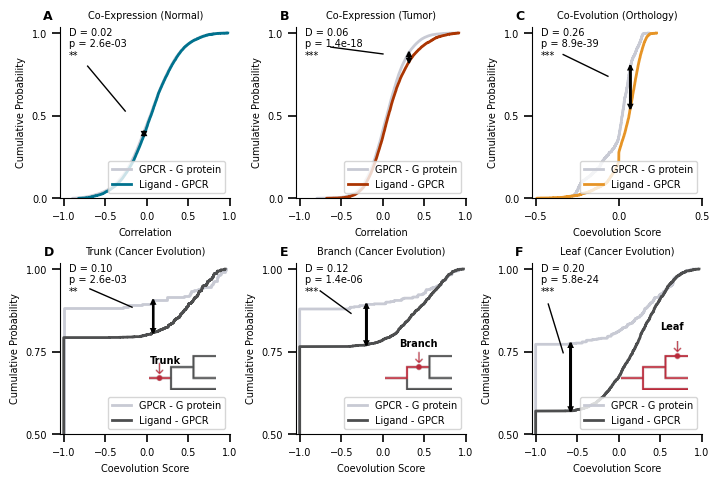

In [18]:
from scipy.stats import ks_2samp
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fs = 7

# Create figure
fig, axes = plt.subplot_mosaic(
    mosaic="""
    ABC
    DEF
    """,
    figsize=(7.08, 4.72),
    constrained_layout=True
)

# Separate the conditions for df and df_coev
co_expression_conditions = ['Normal Co-Expression', 'Tumor Co-Expression', 'Normal Co-Evolution']
coev_conditions = ['Trunk Co-Evolution', 'Branch Co-Evolution', 'Leaf Co-Evolution']

ks_stats = []
p_vals = []

# Run KS test for co-expression conditions using df
for condition in co_expression_conditions:
    print(condition)
    ks_stat, p_value = get_pvals_stats(df, condition)  # df for co-expression
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

# Run KS test for coev conditions using df_coev
for condition in coev_conditions:
    ks_stat, p_value = get_pvals_stats(df_coev, condition)  # df_coev for coev indices
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

# Apply FDR correction using false_discovery_control
corrected_pvals = false_discovery_control(p_vals)

ylim_normal = (0., 1.04)

# Co-expression plots — use defaults
plot_cdf_with_ks(df, 'Normal Co-Expression', axes['A'], ks_stats[0], corrected_pvals[0], ncolor     , lightgray, ylim=ylim_normal, text_coords=(0.05, 0.9), text_ha='left', xlim=(-1.04, 1.0))
plot_cdf_with_ks(df, 'Tumor Co-Expression' , axes['B'], ks_stats[1], corrected_pvals[1], tcolor     , lightgray, ylim=ylim_normal, text_coords=(0.05, 0.9), text_ha='left', xlim=(-1.04, 1.0))
plot_cdf_with_ks(df, 'Normal Co-Evolution' , axes['C'], ks_stats[2], corrected_pvals[2], orangecolor, lightgray, ylim=ylim_normal, text_coords=(0.05, 0.9), text_ha='left', xlim=(-0.52, 0.5))

ylim_tumor = (0.5, 1.02)

# coev plots — customize position and alignment
plot_cdf_with_ks(df_coev, 'Trunk Co-Evolution' , axes['D'], ks_stats[3], corrected_pvals[3], graycolor, lightgray, ylim=ylim_tumor, text_coords=(0.05, 0.9), text_ha='left', xlim=(-1.04, 1.0))
plot_cdf_with_ks(df_coev, 'Branch Co-Evolution', axes['E'], ks_stats[4], corrected_pvals[4], graycolor, lightgray, ylim=ylim_tumor, text_coords=(0.05, 0.9), text_ha='left', xlim=(-1.04, 1.0))
plot_cdf_with_ks(df_coev, 'Leaf Co-Evolution',   axes['F'], ks_stats[5], corrected_pvals[5], graycolor, lightgray, ylim=ylim_tumor, text_coords=(0.05, 0.9), text_ha='left', xlim=(-1.04, 1.0))

# X-axis labels
axes['A'].set_xlabel('Correlation')
axes['B'].set_xlabel('Correlation')
axes['C'].set_xlabel('Coevolution Score')
axes['D'].set_xlabel('Coevolution Score')
axes['E'].set_xlabel('Coevolution Score')
axes['F'].set_xlabel('Coevolution Score')

# Titles
axes['A'].set_title('Co-Expression (Normal)', fontsize=fs)
axes['B'].set_title('Co-Expression (Tumor)', fontsize=fs)
axes['C'].set_title('Co-Evolution (Orthology)', fontsize=fs)
axes['D'].set_title('Trunk (Cancer Evolution)', fontsize=fs)
axes['E'].set_title('Branch (Cancer Evolution)', fontsize=fs)
axes['F'].set_title('Leaf (Cancer Evolution)', fontsize=fs)

#axes['D'].set_xticks([0, 0.5, 1])
#axes['E'].set_xticks([0, 0.5, 1])
#axes['F'].set_xticks([0, 0.25, 0.5])

axes['D'].set_yticks([0.5, 0.75, 1])
axes['E'].set_yticks([0.5, 0.75, 1])
axes['F'].set_yticks([0.5, 0.75, 1])

icons_path = '/home/lnemati/pathway_crosstalk/data/coev_icons'

# === Icon controls ===
icon_scaling_factor = 0.15  # Adjust size of the icons

# === Add icons to panels D, E, and F ===
icon_files = {
    'D': 'trunk_reverse.png',
    'E': 'branch_reverse.png',
    'F': 'leaf_reverse.png',
}

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

for panel, icon_name in icon_files.items():
    icon_path = os.path.join(icons_path, icon_name)
    if os.path.exists(icon_path):
        # Load and resize icon
        icon = Image.open(icon_path)
        width, height = icon.size
        icon_resized = icon.resize((int(width * icon_scaling_factor), int(height * icon_scaling_factor)))
        icon_array = np.array(icon_resized)

        # Create image box
        imagebox = OffsetImage(icon_array, zoom=0.5, resample=True)

        # Position in axes-relative coordinates (x=0.78, y=0.28 is consistent)
        ab = AnnotationBbox(
            imagebox,
            (0.72, 0.4),           # Position of the icon
            xycoords='axes fraction',
            frameon=False
        )

        axes[panel].add_artist(ab)

        # === Add label text above the icon ===
        label_map = {'D': 'Trunk', 'E': 'Branch', 'F': 'Leaf'}
        offsetx = {'D': -0.1,'E': 0, 'F': 0.1}
        offsety = {'D': -0.1,'E': 0, 'F': 0.1}
        axes[panel].text(
            0.72 + offsetx[panel],
            0.50 + offsety[panel],
            label_map[panel],
            transform=axes[panel].transAxes,
            ha='center',
            va='bottom',
            fontsize=fs,
            fontweight='bold'
        )

for ax in axes.values():
    ax.tick_params(length=6, width=1.2)

# === Add panel letters ===
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']
for label, ax in zip(panel_labels, axes.values()):
    ax.text(
        -0.1, 1.1,  # Top-left corner in axes coords
        label,
        transform=ax.transAxes,
        fontsize=fs+2,
        fontweight='bold',
        va='top',
        ha='left'
    )
    

# In the legend replace 'G-Protein' with 'GPCR-Gprotein' and 'Ligand' with 'Ligand-GPCR'
for ax in axes.values():
    handles, labels = ax.get_legend_handles_labels()
    new_labels = []
    for label in labels:
        if label == 'G-Protein':
            new_labels.append('GPCR - G protein')
        elif label == 'Ligand':
            new_labels.append('Ligand - GPCR')
        else:
            new_labels.append(label)
    ax.legend(handles, new_labels, fontsize=fs, loc='lower right')

# -----------------------------
# Save
# -----------------------------
name = 'NEW_2'
figures_dir = '/home/lnemati/pathway_crosstalk/results/figures/new_figures'
os.makedirs(os.path.join(figures_dir, name), exist_ok=True)

plt.savefig(os.path.join(figures_dir, name, name) + '.pdf', bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(figures_dir, name, name) + '.png', bbox_inches='tight', dpi=300)

plt.show()


In [22]:
fig_to_panels(fig, axes, output_dir='/home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_2/panels')

Saved panel 'Co-Expression (Normal)' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_2/panels/co-expression_(normal)
Saved panel 'Co-Expression (Tumor)' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_2/panels/co-expression_(tumor)
Saved panel 'Co-Evolution (Orthology)' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_2/panels/co-evolution_(orthology)
Saved panel 'Trunk (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_2/panels/trunk_(cancer_evolution)
Saved panel 'Branch (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_2/panels/branch_(cancer_evolution)
Saved panel 'Leaf (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_2/panels/leaf_(cancer_evolution)
